In [94]:
#Applyling all the metrics on our data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [95]:
import os
print(os.getcwd())
print(os.listdir())

/Users/smritimishra/PycharmProjects/ML-Tutorials/06_modelling
['multiple_linear_regression.ipynb', 'grid_search.ipynb', 'linear_regression_intro.ipynb', 'regression_metrics.ipynb', 'linear_regression_math.ipynb']


In [96]:
print(os.listdir())  # you already did, no 'data' folder shown


['multiple_linear_regression.ipynb', 'grid_search.ipynb', 'linear_regression_intro.ipynb', 'regression_metrics.ipynb', 'linear_regression_math.ipynb']


In [97]:
df = pd.read_csv("../data/placement.csv")


In [98]:
print(df.head())


   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


In [99]:
df.shape


(200, 2)

In [100]:
print(df.sample(10))

     cgpa  package
149  8.28     3.67
16   6.84     2.35
127  6.78     3.11
135  6.10     2.60
111  5.42     2.25
150  6.30     2.73
56   5.84     2.74
92   7.90     4.00
40   9.38     4.02
5    7.89     2.99


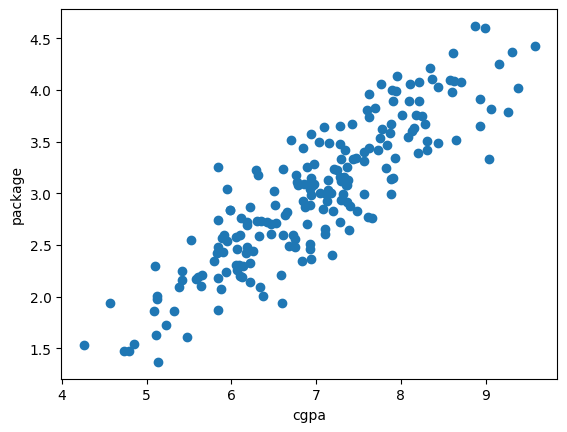

In [101]:
plt.scatter(df['cgpa'] ,df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [102]:
x = df.iloc[: , 0:1]
y = df.iloc[:,-1]

In [103]:
print(x)


     cgpa
0    6.89
1    5.12
2    7.82
3    7.42
4    6.94
..    ...
195  6.93
196  5.89
197  7.21
198  7.63
199  6.22

[200 rows x 1 columns]


In [104]:
print(y)

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


In [105]:
from sklearn.model_selection import train_test_split

In [106]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size =0.2 , random_state = 2)

In [107]:
from sklearn.linear_model import LinearRegression


In [108]:
lr = LinearRegression()


In [109]:
lr.fit(x_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.56]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8961
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [110]:
y_pred = lr.predict(x_test)


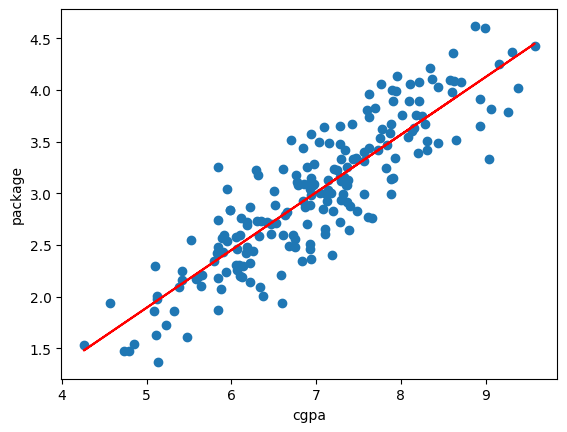

In [111]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(x_train , lr.predict(x_train), color = 'red')
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [112]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [113]:
lr.predict(x_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [114]:
y_test.values



array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [115]:
print("MAE" , mean_absolute_error(y_test,y_pred))
#unit of mae is lpa

MAE 0.2884710931878175


In [116]:
print("MSE :" , mean_squared_error(y_test , y_pred))
#unit not same as package


MSE : 0.12129235313495527


In [117]:
print("RMSE :" , np.sqrt(mean_squared_error(y_test ,y_pred)) )
#unit of rmse is in lpa

RMSE : 0.34827051717731616


In [118]:
print("r2score" , r2_score(y_test , y_pred))
#not very great but not too bad either


r2score 0.780730147510384


In [119]:
#Adjusted r2 score
r2 =  r2_score(y_test , y_pred)
1-((1 - r2)*(40-1))/(40 -1-1)


0.7749598882343415

In [120]:
df.shape

(200, 2)

In [121]:
#proving that adjusted r2 score lowers its value when an irrelevant column is added .

newdf = df.copy()
newdf['random_feature'] = np.random.random(200)

newdf = newdf[['cgpa', 'random_feature' ,'package']]


In [122]:
print(newdf.head())


   cgpa  random_feature  package
0  6.89        0.835160     3.26
1  5.12        0.403078     1.98
2  7.82        0.334712     3.25
3  7.42        0.785811     3.67
4  6.94        0.826265     3.57


Text(0, 0.5, 'package(in lpa')

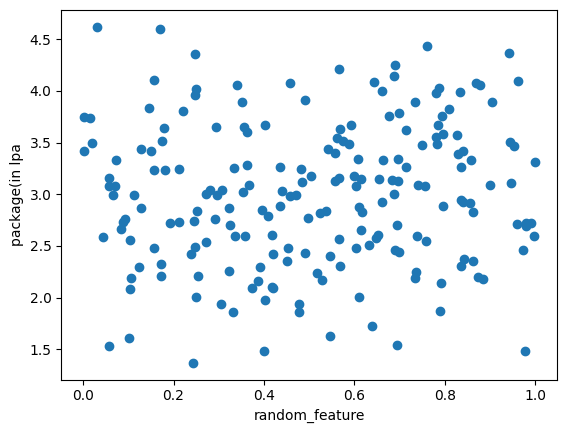

In [123]:
plt.scatter(newdf['random_feature'], newdf['package'])
plt.xlabel('random_feature')
plt.ylabel('package(in lpa')

In [124]:
x = newdf.iloc[:,0:2]
y = newdf.iloc[:,-1]

In [125]:
x_train , x_test, y_train , y_test = train_test_split(x, y , test_size = 0.2 , random_state = 2)

In [126]:
lr = LinearRegression()

In [127]:
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 0.56,-0.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','random_feature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.854
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [128]:
y_pred2 = lr.predict(x_test)

In [129]:
print("new r2 score :" , r2_score(y_test , y_pred2))

new r2 score : 0.7791193927966934


In [130]:
x_test.shape

(40, 2)

In [131]:
newr2 = r2_score(y_test , y_pred2)
1- ((1-newr2)*(40-1))/(40-1-2)

0.7671799005154336

In [132]:
#now doing the same process to prove that adjusted r2score increases its value on adding a relevant column is added

newdf2 = df.copy()
newdf2['iq'] = df['package'] +(np.random.randint(-12 , 12 , 200)/10)
newdf2 = newdf2[['cgpa', 'iq' , 'package']]

In [133]:
print(newdf2.head())


   cgpa    iq  package
0  6.89  3.76     3.26
1  5.12  1.38     1.98
2  7.82  2.65     3.25
3  7.42  4.47     3.67
4  6.94  2.97     3.57


In [134]:
import matplotlib.pyplot as plt

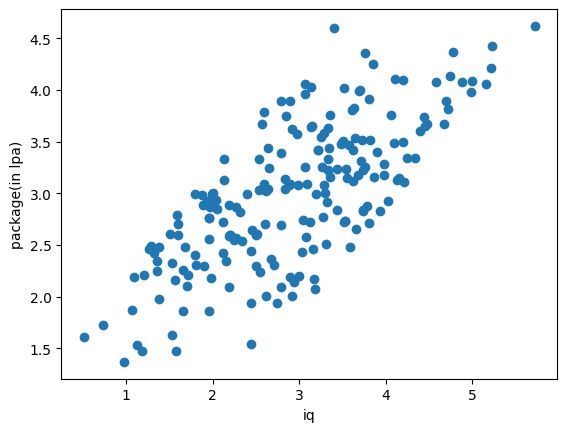

In [135]:
plt.scatter(newdf2['iq'], newdf2['package'])
plt.xlabel('iq')
plt.ylabel('package(in lpa)')
plt.show()

In [136]:
x = newdf2.iloc[:, 0:2]
y = newdf2.iloc[:,-1]

In [137]:
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2 , random_state = 2)

In [138]:
lr = LinearRegression()

In [139]:
lr.fit(x_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.44,0.2 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','iq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.6734
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [140]:
y_pred = lr.predict(x_test)


In [141]:
#calculating r2 score
print("r2score:" , r2_score(y_test , y_pred))

r2score: 0.8457328976549423


In [142]:
x_test.shape

(40, 2)

In [143]:
#adjusted r2 score
newr2 = r2_score(y_test , y_pred)
1- (((1-newr2)*(40-1))/(40-1-2))

0.8373941353660203